# Statistics is about differences, relationships, and predictions

Original stata code:

```
* Install libraries
ssc install scatterfit, replace

* Import data
use "https://github.com/quarcs-lab/data-open/raw/master/auto/auto.dta", clear
des
sum

* Generate observation ID
gen id = _n

* Improve label names
label define foreign 0 "Domestic car", modify
label define foreign 1 "Foreign car", modify

* Explore differences with histograms and boxplots
histogram mpg, kdensity kdenopts(gaussian) by(foreign) by(, legend(off) note("")) xtitle("Car fuel efficiency (Miles per galon)") ytitle("Density") name(hist, replace)
graph hbox mpg, over(foreign) ytitle("Car fuel efficiency (Miles per galon)")  name(box, replace)

* Scatter plot with regression information
scatterfit mpg weight, vce(cluster id) regp(coef sig r2 nobs) parpos(20 4800)  plotscheme(white_tableau) opts(ytitle("Car fuel efficiency (in miles per galon)") xtitle("Car weight (in pounds)") legend(off) name(sc1, replace))
scatterfit mpg weight, by(foreign) vce(cluster id) regp(coef sig r2 nobs) parpos(25 4300) plotscheme(white_tableau) opts(ytitle("Car fuel efficiency (in miles per galon)") xtitle("Car weight (in pounds)") name(sc2, replace))

* Regression with interactions and predictions: Do you see the differences, associations and predictions?
reg mpg c.weight##i.foreign, robust
margins foreign, at(weight=(2000 2500 3000 3500 4000) )
marginsplot, xtitle("Car weight (in pounds)") ytitle("Predicted car fuel efficiency (in miles per galon)") title("")
```

Replication in Python:

## 1. Setup: Import Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Set a consistent style for the plots
sns.set_theme(style="whitegrid")

## 2. Data Loading and Preparation

In [ ]:
# Import data from URL
url = "https://github.com/quarcs-lab/data-open/raw/master/auto/auto.dta"
df = pd.read_stata(url)
df

,make,price,mpg,rep78,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign
0,AMC Concord,4099,22,3.0,2.5,11,2930,186,40,121,3.58,domestic
1,AMC Pacer,4749,17,3.0,3.0,11,3350,173,40,258,2.53,domestic
2,AMC Spirit,3799,22,NaN,3.0,12,2640,168,35,121,3.08,domestic
3,Buick Century,4816,20,3.0,4.5,16,3250,196,40,196,2.93,domestic
4,Buick Electra,7827,15,4.0,4.0,20,4080,222,43,350,2.41,domestic
...,...,...,...,...,...,...,...,...,...,...,...,...
69,VW Dasher,7140,23,4.0,2.5,12,2160,172,36,97,3.74,foreign
70,VW Diesel,5397,41,5.0,3.0,15,2040,155,35,90,3.78,foreign
71,VW Rabbit,4697,25,4.0,3.0,15,1930,155,35,89,3.78,foreign
72,VW Scirocco,6850,25,4.0,2.0,16,1990,156,36,97,3.78,foreign


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   make          74 non-null     object  
 1   price         74 non-null     int16   
 2   mpg           74 non-null     int8    
 3   rep78         69 non-null     float64 
 4   headroom      74 non-null     float64 
 5   trunk         74 non-null     int8    
 6   weight        74 non-null     int16   
 7   length        74 non-null     int16   
 8   turn          74 non-null     int8    
 9   displacement  74 non-null     int16   
 10  gear_ratio    74 non-null     float64 
 11  foreign       74 non-null     category
dtypes: category(1), float64(3), int16(4), int8(3), object(1)
memory usage: 3.4+ KB


In [ ]:
df.describe().round(2)

,price,mpg,rep78,headroom,trunk,weight,length,turn,displacement,gear_ratio
count,74.00,74.00,69.00,74.00,74.00,74.00,74.00,74.00,74.00,74.00
mean,6165.26,21.30,3.41,2.99,13.76,3019.46,187.93,39.65,197.30,3.01
std,2949.50,5.79,0.99,0.85,4.28,777.19,22.27,4.40,91.84,0.46
min,3291.00,12.00,1.00,1.50,5.00,1760.00,142.00,31.00,79.00,2.19
25%,4220.25,18.00,3.00,2.50,10.25,2250.00,170.00,36.00,119.00,2.73
50%,5006.50,20.00,3.00,3.00,14.00,3190.00,192.50,40.00,196.00,2.96
75%,6332.25,24.75,4.00,3.50,16.75,3600.00,203.75,43.00,245.25,3.35
max,15906.00,41.00,5.00,5.00,23.00,4840.00,233.00,51.00,425.00,3.89


In [ ]:
# Generate observation ID
df['id'] = range(1, len(df) + 1)

In [ ]:
# Improve label names by mapping the 'foreign' variable
# The .cat.rename_categories is used because pandas reads it as a categorical type
df['foreign'] = df['foreign'].cat.rename_categories({
    'Domestic': 'Domestic car',
    'Foreign': 'Foreign car'
})

In [ ]:
df

,make,price,mpg,rep78,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign,id
0,AMC Concord,4099,22,3.0,2.5,11,2930,186,40,121,3.58,domestic,1
1,AMC Pacer,4749,17,3.0,3.0,11,3350,173,40,258,2.53,domestic,2
2,AMC Spirit,3799,22,NaN,3.0,12,2640,168,35,121,3.08,domestic,3
3,Buick Century,4816,20,3.0,4.5,16,3250,196,40,196,2.93,domestic,4
4,Buick Electra,7827,15,4.0,4.0,20,4080,222,43,350,2.41,domestic,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,VW Dasher,7140,23,4.0,2.5,12,2160,172,36,97,3.74,foreign,70
70,VW Diesel,5397,41,5.0,3.0,15,2040,155,35,90,3.78,foreign,71
71,VW Rabbit,4697,25,4.0,3.0,15,1930,155,35,89,3.78,foreign,72
72,VW Scirocco,6850,25,4.0,2.0,16,1990,156,36,97,3.78,foreign,73


## Differences

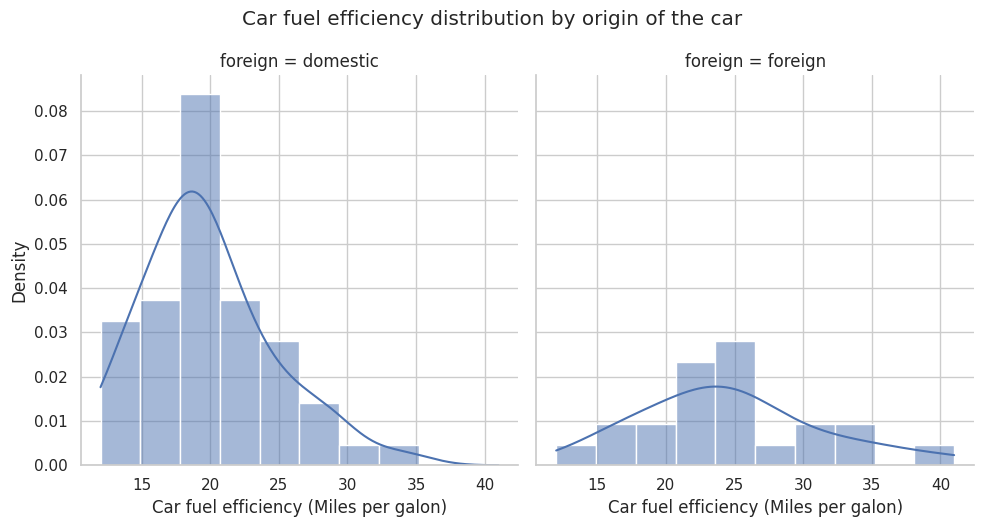

In [ ]:
hist_plot = sns.displot(
    data=df,
    x='mpg',
    col='foreign', # Creates separate plots for each category
    kde=True, # Adds the density line
    stat='density'
)

hist_plot.set_axis_labels("Car fuel efficiency (Miles per galon)", "Density")
plt.suptitle("Car fuel efficiency distribution by origin of the car", y=1.05);

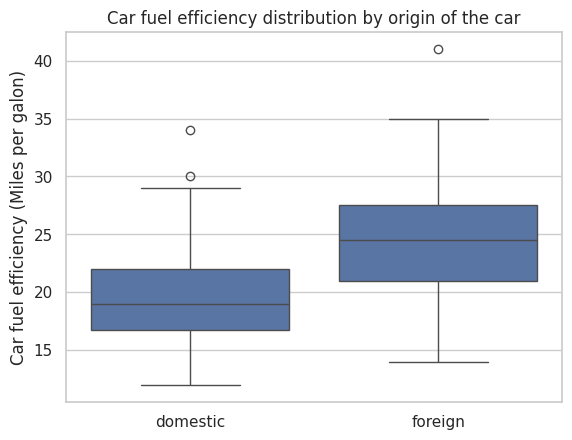

In [ ]:
sns.boxplot(data=df, x='foreign', y='mpg')
plt.ylabel("Car fuel efficiency (Miles per galon)")
plt.xlabel("") # Remove x-axis label for a cleaner look
plt.title("Car fuel efficiency distribution by origin of the car");

## Relationships

In [ ]:
# Run a simple OLS regression to get stats for annotation
model_simple = smf.ols('mpg ~ weight', data=df).fit(cov_type='cluster', cov_kwds={'groups': df['id']})
stats_text = (
    f"Coef: {model_simple.params['weight']:.4f}\n"
    f"P>|t|: {model_simple.pvalues['weight']:.4f}\n"
    f"R-squared: {model_simple.rsquared:.4f}\n"
    f"Obs: {int(model_simple.nobs)}"
)

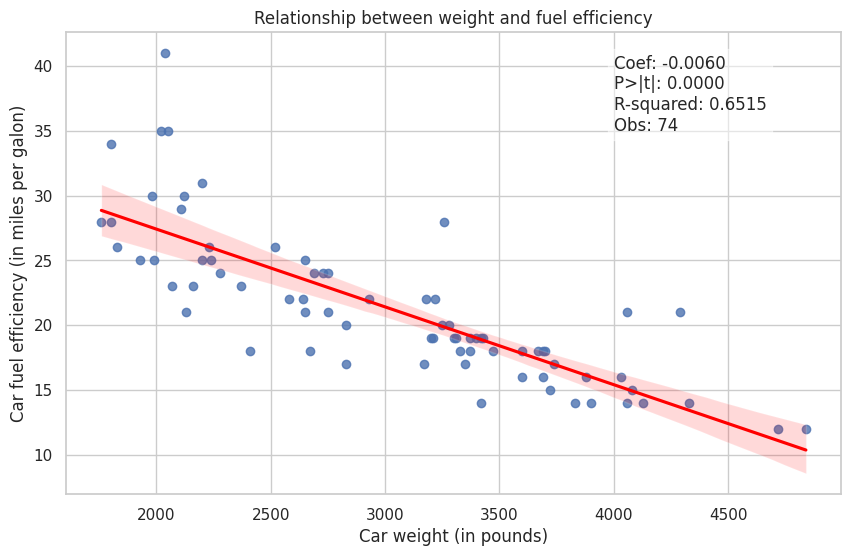

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='weight', y='mpg', line_kws={"color": "red"})
plt.text(4000, 35, stats_text, bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel("Car weight (in pounds)")
plt.ylabel("Car fuel efficiency (in miles per galon)")
plt.title("Relationship between weight and fuel efficiency");

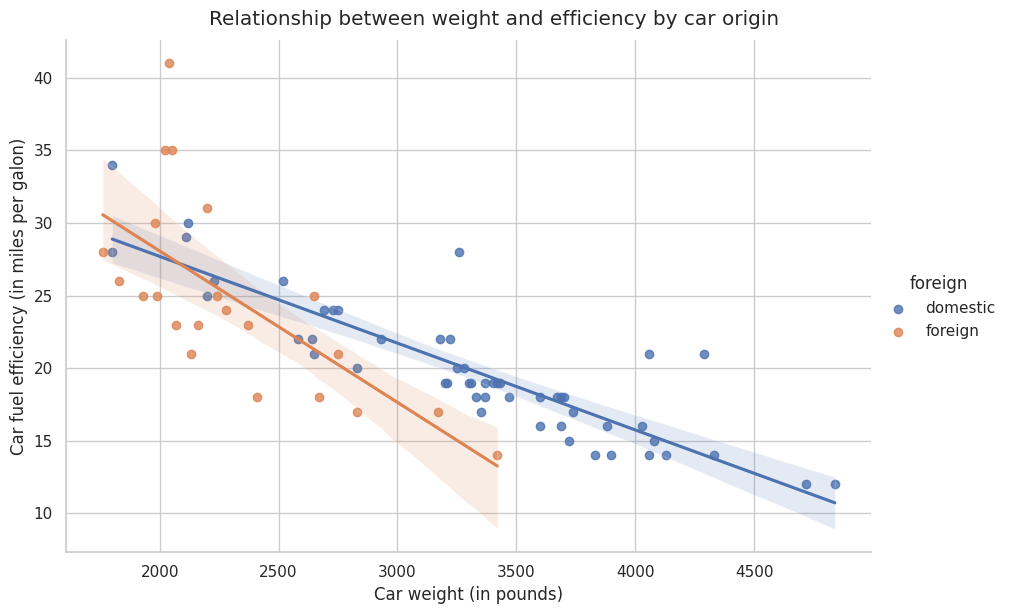

In [ ]:
g = sns.lmplot(
    data=df,
    x='weight',
    y='mpg',
    hue='foreign', # Differentiates points and lines by category
    height=6,
    aspect=1.5
)
g.set_axis_labels("Car weight (in pounds)", "Car fuel efficiency (in miles per galon)")
g.fig.suptitle("Relationship between weight and efficiency by car origin", y=1.02);

## Predictions

In [ ]:
# In Stata: reg mpg c.weight##i.foreign, robust (includes main effects and the interaction)
model_interact = smf.ols('mpg ~ weight * foreign', data=df).fit(cov_type='HC1') # HC1 is a common robust SE
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     53.36
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           4.64e-18
Time:                        03:50:33   Log-Likelihood:                -191.03
No. Observations:                  74   AIC:                             390.1
Df Residuals:                      70   BIC:                             399.3
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
# In Stata: margins foreign, at(weight=(2000 2500 3000 3500 4000))
# In Python:  Create a new dataframe for predictions
weights_to_predict = [2000, 2500, 3000, 3500, 4000]
predict_df = pd.DataFrame({
    'weight': weights_to_predict * 2, # Repeat weights for each category
    'foreign': ['domestic'] * len(weights_to_predict) + ['foreign'] * len(weights_to_predict)
})
predict_df

,weight,foreign
0,2000,domestic
1,2500,domestic
2,3000,domestic
3,3500,domestic
4,4000,domestic
5,2000,foreign
6,2500,foreign
7,3000,foreign
8,3500,foreign
9,4000,foreign


In [ ]:
# Get predictions and confidence intervals
predictions = model_interact.get_prediction(predict_df).summary_frame()
predictions

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,27.696797,0.775670,26.176513,29.217082,21.074938,34.318657
1,24.709256,0.540081,23.650717,25.767795,18.177926,31.240585
2,21.721714,0.360618,21.014915,22.428513,15.238094,28.205334
3,18.734172,0.341669,18.064513,19.403831,12.254496,25.213848
4,15.746630,0.501761,14.763197,16.730064,9.227052,22.266209
5,28.066382,1.451677,25.221147,30.911617,21.021304,35.111460
6,22.853403,0.847188,21.192946,24.513861,16.197963,29.508843
7,17.640424,0.835765,16.002355,19.278494,10.990535,24.290314
8,12.427446,1.431676,9.621413,15.233479,5.398108,19.456783
9,7.214467,2.184331,2.933256,11.495678,-0.522879,14.951813


In [ ]:

predict_df['predicted_mpg'] = predictions['mean']
predict_df['ci_lower']      = predictions['mean_ci_lower']
predict_df['ci_upper']      = predictions['mean_ci_upper']

predict_df

,weight,foreign,predicted_mpg,ci_lower,ci_upper
0,2000,domestic,27.696797,26.176513,29.217082
1,2500,domestic,24.709256,23.650717,25.767795
2,3000,domestic,21.721714,21.014915,22.428513
3,3500,domestic,18.734172,18.064513,19.403831
4,4000,domestic,15.746630,14.763197,16.730064
5,2000,foreign,28.066382,25.221147,30.911617
6,2500,foreign,22.853403,21.192946,24.513861
7,3000,foreign,17.640424,16.002355,19.278494
8,3500,foreign,12.427446,9.621413,15.233479
9,4000,foreign,7.214467,2.933256,11.495678


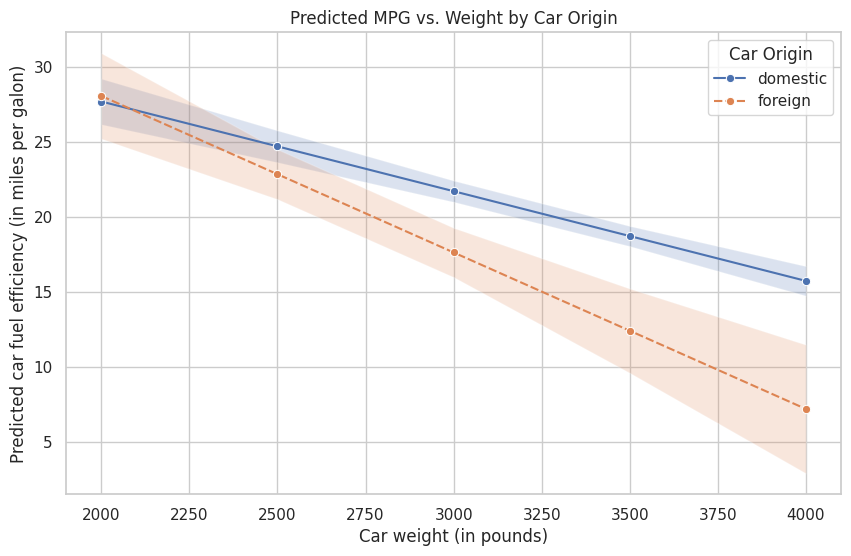

In [ ]:
# Stata: marginsplot ...
# Plot the predicted values (margins plot)
plt.figure(figsize=(10, 6))
sns.lineplot(data=predict_df, x='weight', y='predicted_mpg', hue='foreign', marker='o', style='foreign')

# Add confidence interval ribbons
for car_type in predict_df['foreign'].unique():
    subset = predict_df[predict_df['foreign'] == car_type]
    plt.fill_between(subset['weight'], subset['ci_lower'], subset['ci_upper'], alpha=0.2)

plt.xlabel("Car weight (in pounds)")
plt.ylabel("Predicted car fuel efficiency (in miles per galon)")
plt.title("Predicted MPG vs. Weight by Car Origin")
plt.legend(title='Car Origin');